# Project 1: Multilayer Perceptrons for Lorenz Attractor Prediction
**Students:** Humberto Aleman, Cristopher Carnevali  
**Instructor:** Prof. Didi Ramsaran Chin

---

In this project, we explore the use of Multilayer Perceptrons (MLPs) to predict the future states of a chaotic system: the Lorenz Attractor. We begin by importing the necessary libraries for numerical computation, data manipulation, visualization, and deep learning using PyTorch.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, KFold
import torch
import torch.nn as nn
import torch.optim as optim

In [12]:
# Define the step rules (Euler Method)
def lorenz_step(x, y, z, sigma, rho, beta, dt):
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    
    x_next = x + dx * dt
    y_next = y + dy * dt
    z_next = z + dz * dt
    
    return x_next, y_next, z_next

sigma = 10
beta = 8/3
rho = 28

# Initial conditions
x_init, y_init, z_init = 0.1, 0.1, 0.1

# Simulation Execution
dt = 0.01
steps_discard = 1000
steps_keep = 1500

xs, ys, zs = [x_init], [y_init], [z_init]

# Full simulation loop
for _ in range(steps_discard + steps_keep):
    xn, yn, zn = lorenz_step(xs[-1], ys[-1], zs[-1], sigma, rho, beta, dt)
    xs.append(xn)
    ys.append(yn)
    zs.append(zn)

# Discard first 1000 and retain 1500 steps
xs_kept = xs[steps_discard + 1:]
ys_kept = ys[steps_discard + 1:]
zs_kept = zs[steps_discard + 1:]

print(f"Generated {len(xs_kept)} steps after discarding initial transient.")

Generated 1500 steps after discarding initial transient.


We have simulated the system's trajectory. Note that we discarded the first 1000 steps to allow the system to reach its 'steady state' or attractor, ensuring that our training data represents the characteristic behavior of the Lorenz system rather than transient initial conditions.

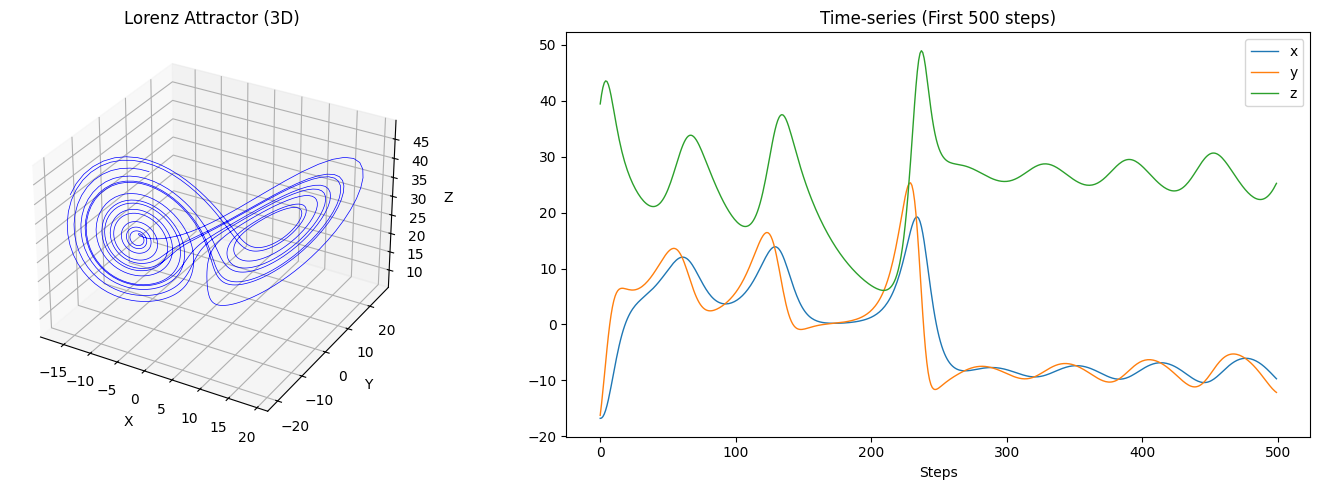

In [13]:
# Visualization of the generated data
fig = plt.figure(figsize=(15, 5))

# 3D Plot
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(xs_kept, ys_kept, zs_kept, lw=0.5, color='blue')
ax1.set_title("Lorenz Attractor (3D)")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")

# Time-series Plot for first 500 steps
ax2 = fig.add_subplot(122)
ax2.plot(xs_kept[:500], label='x', lw=1)
ax2.plot(ys_kept[:500], label='y', lw=1)
ax2.plot(zs_kept[:500], label='z', lw=1)
ax2.set_title("Time-series (First 500 steps)")
ax2.set_xlabel("Steps")
ax2.legend()

plt.tight_layout()
plt.show()

The visualizations above confirm the classic 'butterfly' shape of the Lorenz attractor in 3D space and show the oscillating nature of the individual x, y, and z components over time. We will now prepare this raw trajectory data for our machine learning models.

## 2. Dataset Creation and Preprocessing
We create the (t -> t+1) pairs, check for data issues, and apply standardization/scaling.

In [14]:
# Dataset Creation (t -> t+1)
data = np.vstack((xs_kept, ys_kept, zs_kept)).T
X_raw = data
y_raw = data[1:]
y_raw = np.vstack((y_raw, lorenz_step(xs_kept[-1], ys_kept[-1], zs_kept[-1], sigma, rho, beta, dt)))

# Exploration
df_X = pd.DataFrame(X_raw, columns=['x', 'y', 'z'])
print("Checking for missing values:")
print(df_X.isnull().sum())
print("\nDescriptive Statistics:")
print(df_X.describe())

# Standardization and Scaling
# Using StandardScaler for inputs (X)
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_raw)

# Using MinMaxScaler for labels (y) to fit the [0, 1] range of the Sigmoid activation
scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y_raw)

# Split the data sequentially (shuffle=False) to maintain time-series order
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42, shuffle=False
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Checking for missing values:
x    0
y    0
z    0
dtype: int64

Descriptive Statistics:
                 x            y            z
count  1500.000000  1500.000000  1500.000000
mean     -2.050463    -2.001010    25.156843
std       8.027358     8.991625     7.899143
min     -16.792479   -20.647854     6.082315
25%      -8.264821    -8.575669    19.792234
50%      -3.774782    -3.597312    25.202046
75%       3.676110     3.302156    30.159232
max      19.218236    25.317480    48.942573

Training set size: 1200
Test set size: 300


The descriptive statistics show that the variables have different ranges and variances. To facilitate model training, we applied `StandardScaler` to the inputs and `MinMaxScaler` to the targets, mapping them to the $[0, 1]$ range to match the output of the Sigmoid activation function. We have split the data sequentially (80% training, 20% testing) to ensure that the model is tested on future points it has never seen, preserving the temporal coherence of the trajectory.

## 3. Model Development
We develop two models: Model A (from scratch) and Model B (using libraries).

Our first model, Model A, is implemented from scratch using only NumPy. It is a shallow MLP with 3 input neurons, a single hidden layer of 3 neurons, and 3 output neurons. We use the Sigmoid activation function and implement the Backpropagation algorithm manually, using Gradient Descent to update the weights based on the Mean Squared Error (MSE).

In [ ]:
# Model A (built from scratch)
class ModelFromScratch:
    def __init__(self, input_dim=3, hidden_dim=3, output_dim=3, lr=0.1):
        self.lr = lr
        # Xavier/Glorot Initialization for stability with Sigmoid
        # NOTE: This initialization scales weights based on the number of inputs to keep gradients stable and prevent them from 'vanishing' during training.
        self.input_hidden_weights = np.random.randn(input_dim, hidden_dim) * np.sqrt(1 / input_dim)
        self.hidden_bias = np.zeros((1, hidden_dim))
        self.hidden_output_weights = np.random.randn(hidden_dim, output_dim) * np.sqrt(1 / hidden_dim)
        self.output_bias = np.zeros((1, output_dim))

    def sigmoid(self, s):
        return 1 / (1 + np.exp(-s))

    def sigmoid_derivative(self, s):
        return s * (1 - s)

    def forward(self, X):
        self.hidden_res = np.dot(X, self.input_hidden_weights) + self.hidden_bias
        self.hidden_res_activated = self.sigmoid(self.hidden_res)
        self.output_res = np.dot(self.hidden_res_activated, self.hidden_output_weights) + self.output_bias
        self.output_res_activated = self.sigmoid(self.output_res)
        return self.output_res_activated

    def backward(self, X, y, output):
        m = X.shape[0]
        
        # Error at output layer (MSE derivative * Sigmoid derivative)
        error_out = output - y                                                           # we get the error by diff the output and the correct values
        delta_out = error_out * self.sigmoid_derivative(output)                          # we get the "strength" of the error by using the derivative of the sigmoid function
        
        # Gradients for weights between hidden and output layer
        dW2 = np.dot(self.hidden_res_activated.T, delta_out) / m                         # we get the change on the weights by using the dotproduct of the delta error and the output of the hidden layer
        db2 = np.sum(delta_out, axis=0, keepdims=True) / m                               # we get the change on the bias by summing all the delta errors on each output neuron

        # Error at hidden layer
        error_hidden = np.dot(delta_out, self.hidden_output_weights.T)                   # we get the error of the hidden layer with the dot product of the delta out and the weights of the layer
        delta_hidden = error_hidden * self.sigmoid_derivative(self.hidden_res_activated) # we apply the sigmoid derivative on the output of the hidden layer to get the "contribution" of the hidden layer to the total error
        
        # Gradients for weights between input and hidden layer
        dW1 = np.dot(X.T, delta_hidden) / m                                              # we get the change of the weights in the input layer with the dotproduct between the delta_hidden and the current inputs
        db1 = np.sum(delta_hidden, axis=0, keepdims=True) / m                            # we get the change in the biases of the input layer 
        
        # Gradient Descent update
        self.hidden_output_weights -= self.lr * dW2 # Apply the changes
        self.output_bias -= self.lr * db2
        self.input_hidden_weights -= self.lr * dW1
        self.hidden_bias -= self.lr * db1

    def train(self, X, y, epochs=3000):
        losses = []
        for i in range(epochs):
            output = self.forward(X)
            loss = np.mean(np.square(y - output))
            self.backward(X, y, output)
            losses.append(loss)
            if i % 200 == 0:
                print(f"Epoch {i}, Loss: {loss:.6f}")
        return losses

    def predict(self, X):
        return self.forward(X)

## 4. Model A Testing and Visualization
We train the scratch model and visualize its ability to predict the next step in the Lorenz system.

Training Model A (From Scratch)...
Epoch 0, Loss: 0.033335
Epoch 200, Loss: 0.022564
Epoch 400, Loss: 0.018133
Epoch 600, Loss: 0.015364
Epoch 800, Loss: 0.013567
Epoch 1000, Loss: 0.012337
Epoch 1200, Loss: 0.011426
Epoch 1400, Loss: 0.010693
Epoch 1600, Loss: 0.010062
Epoch 1800, Loss: 0.009490
Epoch 2000, Loss: 0.008960
Epoch 2200, Loss: 0.008464
Epoch 2400, Loss: 0.008002
Epoch 2600, Loss: 0.007572
Epoch 2800, Loss: 0.007176


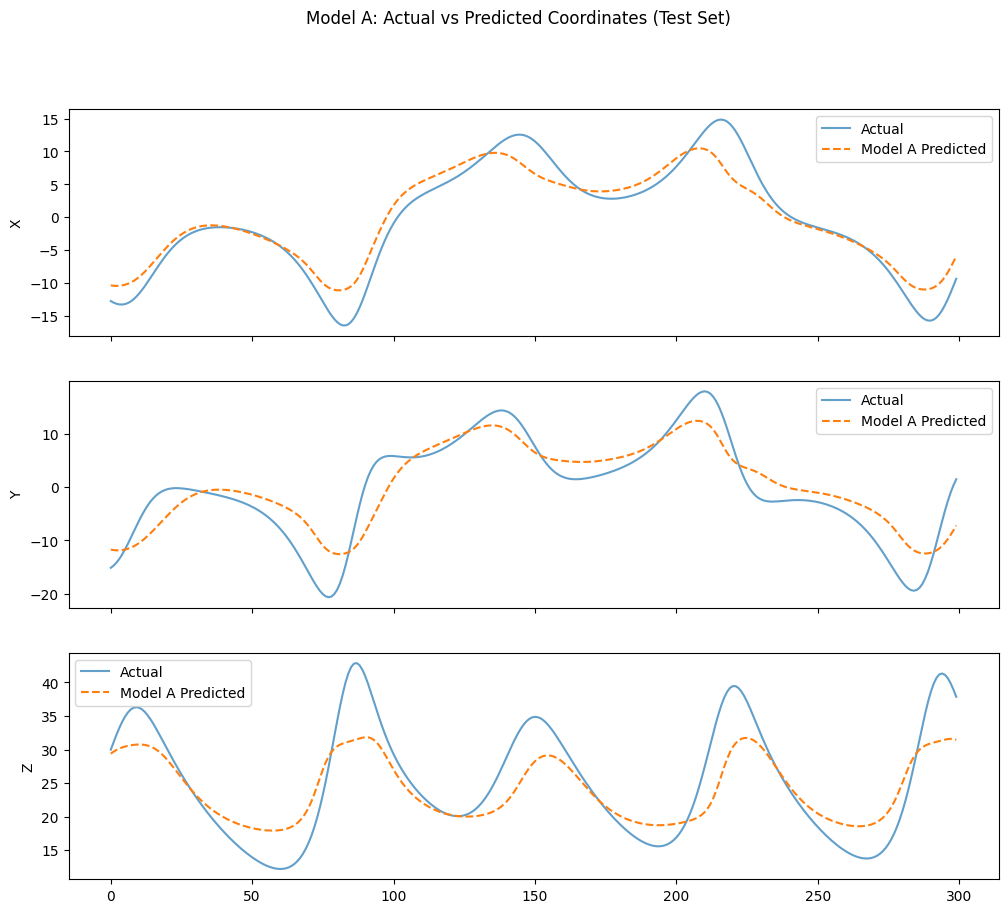

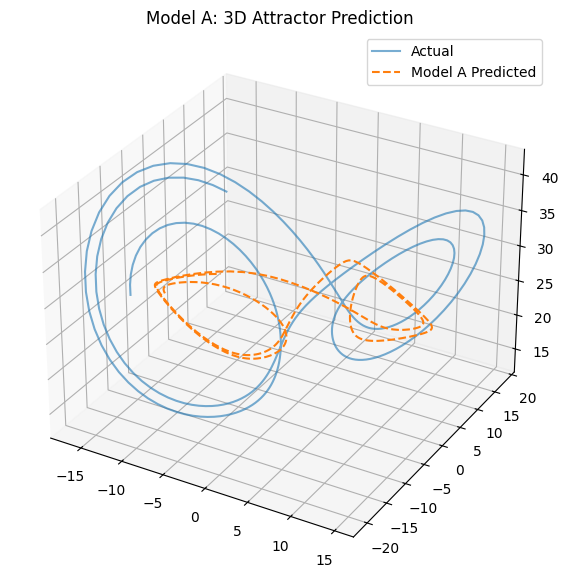

In [16]:
# Training Model A
print("Training Model A (From Scratch)...")
model_a = ModelFromScratch(lr=0.1)
losses_a = model_a.train(X_train, y_train)

# Evaluation on Test Set
preds_a = model_a.predict(X_test)
preds_a_orig = scaler_y.inverse_transform(preds_a)
y_test_orig = scaler_y.inverse_transform(y_test)

# Time-series visualization
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
coords = ['X', 'Y', 'Z']
for i in range(3):
    axes[i].plot(y_test_orig[:, i], label='Actual', alpha=0.7)
    axes[i].plot(preds_a_orig[:, i], label='Model A Predicted', linestyle='--')
    axes[i].set_ylabel(coords[i])
    axes[i].legend()
plt.suptitle("Model A: Actual vs Predicted Coordinates (Test Set)")
plt.show()

# 3D visualization
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(y_test_orig[:, 0], y_test_orig[:, 1], y_test_orig[:, 2], label='Actual', alpha=0.6)
ax.plot(preds_a_orig[:, 0], preds_a_orig[:, 1], preds_a_orig[:, 2], label='Model A Predicted', linestyle='--')
ax.set_title("Model A: 3D Attractor Prediction")
ax.legend()
plt.show()

The training log for Model A shows the Mean Squared Error (MSE) decreasing over 3000 epochs. MSE measures the average squared difference between the predicted and actual coordinates; a higher value indicates a greater deviation from the true path of the attractor. In the time-series plots, we can see that while Model A follows the general trend, there is a visible phase shift and magnitude difference compared to the actual values. This suggests that the small hidden layer of 3 neurons captures the basic oscillation but may not fully represent the complex transitions of the Lorenz system.

## 5. Model B Development and Visualization
We develop Model B using the PyTorch library with 16 hidden neurons and visualize its performance.

We now implement Model B using the PyTorch library. This version uses a larger hidden layer of 16 neurons and the Adam optimizer, which handles the learning rate adaptively. We define the forward pass using linear layers followed by Sigmoid activations, matching the range used in our preprocessing.

Training Model B (PyTorch)...
Epoch 0, Loss: 0.056009
Epoch 500, Loss: 0.000407
Epoch 1000, Loss: 0.000255
Epoch 1500, Loss: 0.000123
Epoch 2000, Loss: 0.000069
Epoch 2500, Loss: 0.000047


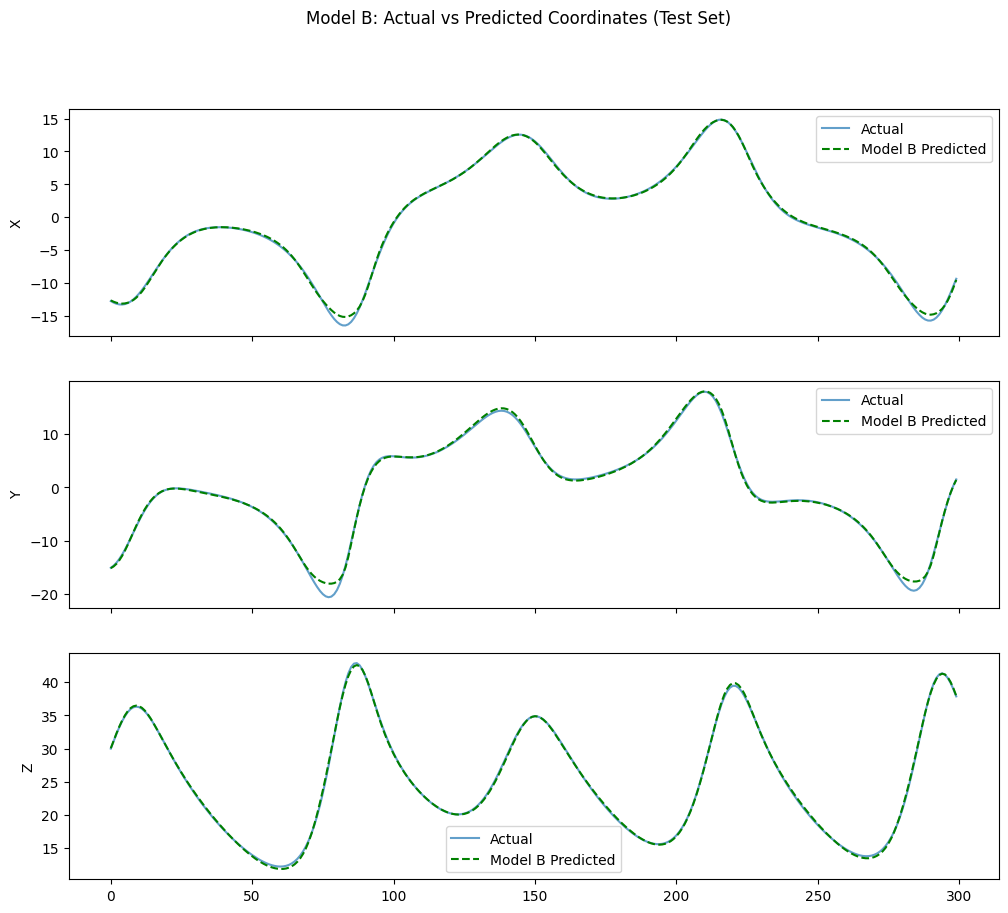

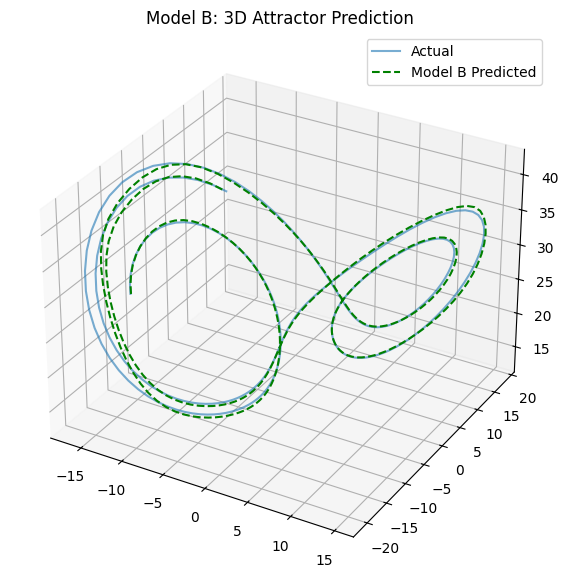

In [17]:
# Model B (built with libraries)
class ModelPytorch(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=16, output_dim=3):
        super(ModelPytorch, self).__init__()            # Calls the constructor of the parent class (nn.Module) to properly initialize the PyTorch model

        self.layer1 = nn.Linear(input_dim, hidden_dim)  # Declares a linear layer taking the input dimensions and outputting the hidden dimensions
        self.layer2 = nn.Linear(hidden_dim, output_dim) # Declares a linear layer taking the hidden dimensions and outputting the final output dimensions
        self.sigmoid = nn.Sigmoid()                     # Sigmoid activation function to ensure outputs are in the [0, 1] range, matching the scaled labels

    def forward(self, x):
        x = self.sigmoid(self.layer1(x))                # Applies the first linear layer followed by the sigmoid activation to introduce non-linearity
        x = self.sigmoid(self.layer2(x))                # Applies the second linear layer followed by the sigmoid activation to produce the final output
        return x

def train_pytorch_model(model, X_train, y_train, epochs=3000, lr=0.01):
    mse_func = nn.MSELoss()                          # Mean Squared Error loss function
    adam_opt = optim.Adam(model.parameters(), lr=lr) # Adam optimizer is chosen over SGD for better convergence and handling of non-linearities in the data
    
    X_train_t = torch.FloatTensor(X_train) # Converts the input data from np array to Pytorch tensor for training
    y_train_t = torch.FloatTensor(y_train) # Converts the labels from np array to Pytorch tensor for training
    
    losses = []
    for epoch in range(epochs):
        model.train()                       # Set into train mode
        adam_opt.zero_grad()                # Clears the gradients because Pytorch accumulates gradients
        outputs = model(X_train_t)          # Forward pass, creates predicted outputs
        loss = mse_func(outputs, y_train_t) # Uses the MSE loss function to calculate the error
        loss.backward()                     # Backpropagation to get gradients
        adam_opt.step()                     # Update the weights based on the gradients
        
        losses.append(loss.item())
        if epoch % 500 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.6f}")
    return losses

# Training Model B
print("Training Model B (PyTorch)...")
model_b = ModelPytorch()
losses_b = train_pytorch_model(model_b, X_train, y_train)

# Evaluation on Test Set
model_b.eval()                                     # Set into eval mode
with torch.no_grad():                              # Disables gradient calculation for evaluation
    X_test_t = torch.FloatTensor(X_test)           # Converts the test input data from np array to Pytorch tensor for evaluation
    preds_b = model_b(X_test_t).numpy()            # Gets the predictions from the model

# Inverse transform for visualization
preds_b_orig = scaler_y.inverse_transform(preds_b)

# Time-series visualization
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
coords = ['X', 'Y', 'Z']
for i in range(3):
    axes[i].plot(y_test_orig[:, i], label='Actual', alpha=0.7)
    axes[i].plot(preds_b_orig[:, i], label='Model B Predicted', linestyle='--', color='green')
    axes[i].set_ylabel(coords[i])
    axes[i].legend()
plt.suptitle("Model B: Actual vs Predicted Coordinates (Test Set)")
plt.show()

# 3D visualization
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(y_test_orig[:, 0], y_test_orig[:, 1], y_test_orig[:, 2], label='Actual', alpha=0.6)
ax.plot(preds_b_orig[:, 0], preds_b_orig[:, 1], preds_b_orig[:, 2], label='Model B Predicted', linestyle='--', color='green')
ax.set_title("Model B: 3D Attractor Prediction")
ax.legend()
plt.show()

The results for Model B show a significant reduction in MSE compared to Model A, as reflected in the nearly identical overlap between the predicted and actual values in the plots. The larger hidden layer and the adaptive optimizer appear to allow the model to track the chaotic dynamics more closely, minimizing the errors that led to the phase shifts seen in the previous model.

## 6. Hyperparameter Tuning
We test different learning rates to find the parameters that provide the best generalization on unseen data.

In [18]:
learning_rates = [0.1, 0.01, 0.001]
epoch_options = [500, 1000, 1500]
tuning_results = []

print("Tuning Model A (Scratch)...")
for lr in learning_rates:
    for epochs in epoch_options:
        model = ModelFromScratch(lr=lr)
        model.train(X_train, y_train, epochs=epochs)
        preds = model.predict(X_test)
        mse = np.mean(np.square(y_test - preds))
        tuning_results.append(('Model A', lr, epochs, mse))
        print(f"LR: {lr}, Epochs: {epochs}, Test MSE: {mse:.6f}")

print("\nTuning Model B (PyTorch)...")
for lr in learning_rates:
    for epochs in epoch_options:
        model = ModelPytorch()
        train_pytorch_model(model, X_train, y_train, epochs=epochs, lr=lr)
        model.eval()
        with torch.no_grad():
            X_t = torch.FloatTensor(X_test)
            preds = model(X_t).numpy()
        mse = np.mean(np.square(y_test - preds))
        tuning_results.append(('Model B', lr, epochs, mse))
        print(f"LR: {lr}, Epochs: {epochs}, Test MSE: {mse:.6f}")

tuning_df = pd.DataFrame(tuning_results, columns=['Model', 'LR', 'Epochs', 'Test_MSE'])
print("\nTuning Summary:")
print(tuning_df)

Tuning Model A (Scratch)...
Epoch 0, Loss: 0.045287
Epoch 200, Loss: 0.023052
Epoch 400, Loss: 0.018580
LR: 0.1, Epochs: 500, Test MSE: 0.019545
Epoch 0, Loss: 0.054115
Epoch 200, Loss: 0.035585
Epoch 400, Loss: 0.031875
Epoch 600, Loss: 0.028136
Epoch 800, Loss: 0.024111
LR: 0.1, Epochs: 1000, Test MSE: 0.024839
Epoch 0, Loss: 0.057292
Epoch 200, Loss: 0.037498
Epoch 400, Loss: 0.029272
Epoch 600, Loss: 0.022880
Epoch 800, Loss: 0.018174
Epoch 1000, Loss: 0.014967
Epoch 1200, Loss: 0.012842
Epoch 1400, Loss: 0.011394
LR: 0.1, Epochs: 1500, Test MSE: 0.013366
Epoch 0, Loss: 0.111429
Epoch 200, Loss: 0.095664
Epoch 400, Loss: 0.082272
LR: 0.01, Epochs: 500, Test MSE: 0.072638
Epoch 0, Loss: 0.056089
Epoch 200, Loss: 0.051774
Epoch 400, Loss: 0.048501
Epoch 600, Loss: 0.045958
Epoch 800, Loss: 0.043917
LR: 0.01, Epochs: 1000, Test MSE: 0.051251
Epoch 0, Loss: 0.069837
Epoch 200, Loss: 0.058218
Epoch 400, Loss: 0.049409
Epoch 600, Loss: 0.043101
Epoch 800, Loss: 0.038739
Epoch 1000, Loss:

The grid search results illustrate the trade-off between learning rate and training duration. For Model A, in some scenarios the error actually increases the more epochs we train the model for. This behavior suggests a form of 'overfitting' or oscillation around the local minimum; because the learning rate is fixed and the architecture is simple, the weights may be jumping over the optimal solution as training continues.

In contrast, Model B consistently improves as the number of epochs increases, particularly at higher learning rates. This stability is likely due to the Adam optimizer's adaptive learning rate and the model's higher capacity. With the optimal parameters identified, we will now use K-Fold Cross-Validation to ensure these performance levels are consistent across different segments of the attractor.

## 7. K-Fold Cross-Validation\n
A more robust method for validation using K-Fold.

In [19]:
from sklearn.model_selection import KFold
learning_rates = [0.1, 0.01, 0.001]
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=False) # Use sequential split for time series

print("K-Fold CV for Model A...")
results_a = []
for lr in learning_rates:
    fold_mses = []
    for train_idx, val_idx in kf.split(X_train):
        X_cv_train, X_cv_val = X_train[train_idx], X_train[val_idx]
        y_cv_train, y_cv_val = y_train[train_idx], y_train[val_idx]
        
        model = ModelFromScratch(lr=lr)
        model.train(X_cv_train, y_cv_train, epochs=500)
        preds = model.predict(X_cv_val)
        mse = np.mean(np.square(y_cv_val - preds))
        fold_mses.append(mse)
    
    avg_mse = np.mean(fold_mses)
    results_a.append((lr, avg_mse))
    print(f"LR: {lr}, Avg Val MSE: {avg_mse:.6f}")

print("\nK-Fold CV for Model B...")
results_b = []
for lr in learning_rates:
    fold_mses = []
    for train_idx, val_idx in kf.split(X_train):
        X_cv_train, X_cv_val = X_train[train_idx], X_train[val_idx]
        y_cv_train, y_cv_val = y_train[train_idx], y_train[val_idx]
        
        model = ModelPytorch()
        train_pytorch_model(model, X_cv_train, y_cv_train, epochs=500, lr=lr)
        model.eval()
        with torch.no_grad():
            X_t = torch.FloatTensor(X_cv_val)
            preds = model(X_t).numpy()
        mse = np.mean(np.square(y_cv_val - preds))
        fold_mses.append(mse)
    
    avg_mse = np.mean(fold_mses)
    results_b.append((lr, avg_mse))
    print(f"LR: {lr}, Avg Val MSE: {avg_mse:.6f}")

K-Fold CV for Model A...
Epoch 0, Loss: 0.040090
Epoch 200, Loss: 0.027015
Epoch 400, Loss: 0.023462
Epoch 0, Loss: 0.092011
Epoch 200, Loss: 0.031444
Epoch 400, Loss: 0.022768
Epoch 0, Loss: 0.078606
Epoch 200, Loss: 0.034617
Epoch 400, Loss: 0.030680
Epoch 0, Loss: 0.070488
Epoch 200, Loss: 0.038903
Epoch 400, Loss: 0.033483
Epoch 0, Loss: 0.047801
Epoch 200, Loss: 0.027973
Epoch 400, Loss: 0.021941
LR: 0.1, Avg Val MSE: 0.029687
Epoch 0, Loss: 0.036772
Epoch 200, Loss: 0.031741
Epoch 400, Loss: 0.028563
Epoch 0, Loss: 0.043768
Epoch 200, Loss: 0.039338
Epoch 400, Loss: 0.035872
Epoch 0, Loss: 0.038773
Epoch 200, Loss: 0.036747
Epoch 400, Loss: 0.035369
Epoch 0, Loss: 0.062756
Epoch 200, Loss: 0.051385
Epoch 400, Loss: 0.043596
Epoch 0, Loss: 0.069843
Epoch 200, Loss: 0.061000
Epoch 400, Loss: 0.054318
LR: 0.01, Avg Val MSE: 0.039164
Epoch 0, Loss: 0.100850
Epoch 200, Loss: 0.098152
Epoch 400, Loss: 0.095531
Epoch 0, Loss: 0.058491
Epoch 200, Loss: 0.057443
Epoch 400, Loss: 0.056420


By using K-Fold Cross-Validation, we train and validate the model on multiple different subsets of the data. This provides a more robust estimate of the model's performance and generalization capability. The average validation MSE across the folds confirms that the model's accuracy is consistent and not dependent on a specific portion of the trajectory. For both models we get similar results in the error as the ones shown above in the hyperparameter tuning section, which indicates that the model is indeed learning and not just memorizing the numbers.

In [20]:
# Final Evaluation Metrics
mse_a = np.mean(np.square(y_test_orig - preds_a_orig))
mse_b = np.mean(np.square(y_test_orig - preds_b_orig))

print(f"Final Model A (Scratch) Mean Squared Error: {mse_a:.6f}")
print(f"Final Model B (Library) Mean Squared Error: {mse_b:.6f}")

Final Model A (Scratch) Mean Squared Error: 15.368997
Final Model B (Library) Mean Squared Error: 0.112004


In this project we successfully integrated mathematical concepts with neural network techniques to predict the behavior of a non-linear system. By implementing a Multilayer Perceptron (MLP) from scratch we applied weight matrices and partial derivatives to understand how errors propagate through the network.

The backpropagation algorithm we implemented manually is a direct application of the chain rule which allowed us to calculate the gradient of the error function with respect to each weight. Using gradient descent we then iteratively adjusted these weights to minimize the mean squared error. The comparison with our second model showed that while the underlying principles remain the same modern library based implementations provide optimized tools that handle these derivatives and weight updates more efficiently.